# Superstore Sales Analysis
## Notebook 03: Product Analysis

### Objective
This notebook analyzes product performance across categories and sub-categories.

The main goals are to:
- Identify which categories generate the most revenue and profit
- Find sub-categories with the highest and lowest profitability
- Detect sub-categories that are generating losses
- Identify top and bottom performing products
- Generate actionable recommendations for product strategy

### Business Questions
1. Which category generates the highest sales and profit?
2. Which sub-category has the highest profit margin?
3. Which sub-categories are generating losses?
4. What are the Top 10 products by sales?
5. What are the Top 10 products by profit?
6. Which products are causing the most financial loss?

In [1]:
# IMPORT LIBRARIES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import os

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', '{:.2f}'.format)

# Visualization style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Create folders if not exist
os.makedirs('images', exist_ok=True)
os.makedirs('reports/tables', exist_ok=True)

print("Libraries imported successfully")

Libraries imported successfully


In [2]:
# LOAD CLEANED DATA 

df = pd.read_csv('data/processed/superstore_cleaned.csv')

# Convert dates
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date']  = pd.to_datetime(df['Ship Date'])

print("Data loaded successfully")
print(f"Shape: {df.shape}")
df.head()

Data loaded successfully
Shape: (9994, 27)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Order Year,Order Month,Order Month Name,Order Quarter,Profit Margin (%),Shipping Days
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.96,2,0.00,41.91,2016,11,Nov,4,16.00,3
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.94,3,0.00,219.58,2016,11,Nov,4,30.00,3
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.62,2,0.00,6.87,2016,6,Jun,2,47.00,4
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.58,5,0.45,-383.03,2015,10,Oct,4,-40.00,7
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.37,2,0.20,2.52,2015,10,Oct,4,11.25,7


In [3]:
# HELPER FUNCTIONS 

def format_currency(value):
    return f"${value:,.2f}"

def format_percent(value):
    return f"{value:.2f}%"

def save_fig(filename):
    plt.savefig(f'images/{filename}', dpi=150, bbox_inches='tight')
    print(f" Saved: images/{filename}")

print("Helper functions ready")

Helper functions ready


## 1. Sales and Profit by Category

Business question:

**Which category generates the highest sales and profit?**

In [4]:
# CATEGORY PERFORMANCE 

category_performance = df.groupby('Category').agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Total_Orders  = ('Order ID', 'nunique'),
    Total_Quantity= ('Quantity', 'sum')
).reset_index()

# Profit Margin
category_performance['Profit_Margin_%'] = (
    category_performance['Total_Profit'] /
    category_performance['Total_Sales'] * 100
).round(2)

# Sales Share
category_performance['Sales_Share_%'] = (
    category_performance['Total_Sales'] /
    category_performance['Total_Sales'].sum() * 100
).round(2)

# Sort by Total Sales
category_performance = category_performance.sort_values(
    'Total_Sales', ascending=False
).reset_index(drop=True)

category_performance

,Category,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%,Sales_Share_%
0,Technology,836154.03,145454.95,1544,6939,17.40,36.40
1,Furniture,741999.80,18451.27,1764,8028,2.49,32.30
2,Office Supplies,719047.03,122490.80,3742,22906,17.04,31.30


In [5]:
# PRINT CATEGORY SUMMARY 

print("=" * 60)
print("CATEGORY PERFORMANCE SUMMARY")
print("=" * 60)

for _, row in category_performance.iterrows():
    print(f"\nCategory: {row['Category']}")
    print(f"  Total Sales:    {format_currency(row['Total_Sales'])}")
    print(f"  Total Profit:   {format_currency(row['Total_Profit'])}")
    print(f"  Profit Margin:  {format_percent(row['Profit_Margin_%'])}")
    print(f"  Sales Share:    {format_percent(row['Sales_Share_%'])}")
    print(f"  Total Orders:   {row['Total_Orders']:,}")

CATEGORY PERFORMANCE SUMMARY

Category: Technology
  Total Sales:    $836,154.03
  Total Profit:   $145,454.95
  Profit Margin:  17.40%
  Sales Share:    36.40%
  Total Orders:   1,544

Category: Furniture
  Total Sales:    $741,999.80
  Total Profit:   $18,451.27
  Profit Margin:  2.49%
  Sales Share:    32.30%
  Total Orders:   1,764

Category: Office Supplies
  Total Sales:    $719,047.03
  Total Profit:   $122,490.80
  Profit Margin:  17.04%
  Sales Share:    31.30%
  Total Orders:   3,742


 Saved: images/category_sales_profit.png


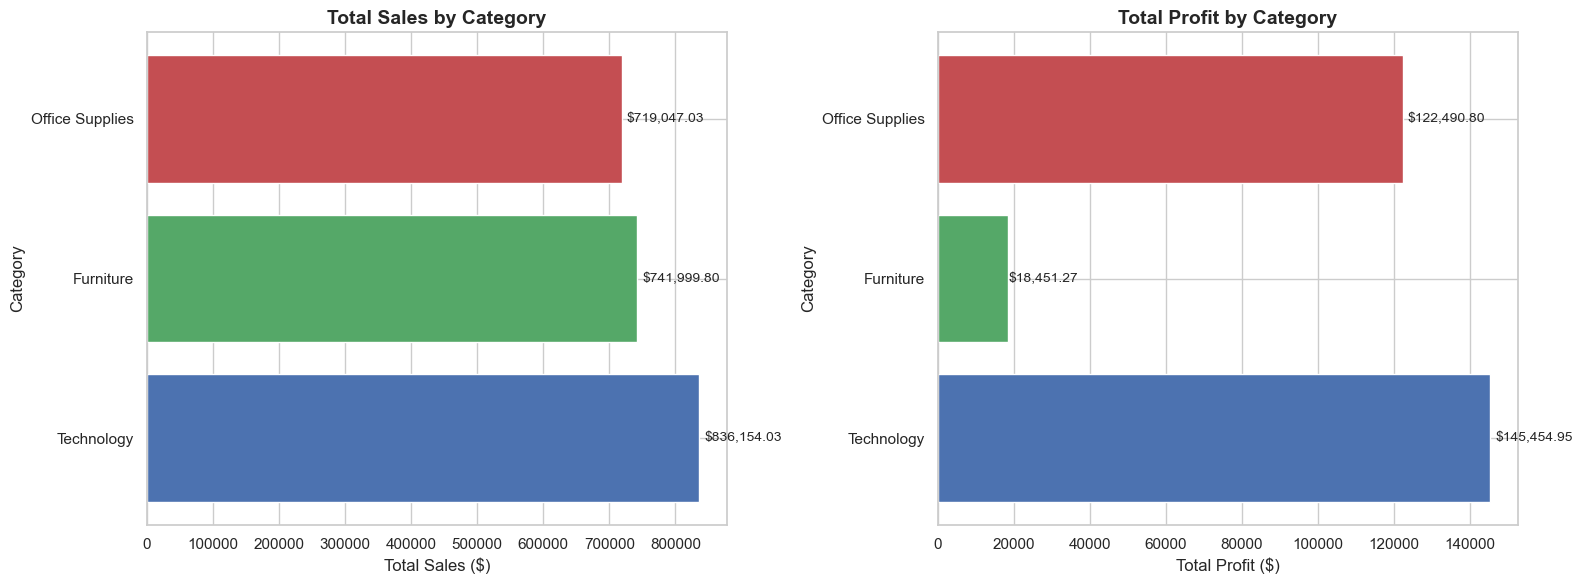

In [6]:
# VISUALIZE SALES BY CATEGORY 

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar Chart: Sales
bars = axes[0].barh(
    category_performance['Category'],
    category_performance['Total_Sales'],
    color=['#4C72B0', '#55A868', '#C44E52']
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    axes[0].text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=10
    )

axes[0].set_title('Total Sales by Category',
                  fontsize=14, fontweight='bold')
axes[0].set_xlabel('Total Sales ($)')
axes[0].set_ylabel('Category')

# --- Bar Chart: Profit ---
bars2 = axes[1].barh(
    category_performance['Category'],
    category_performance['Total_Profit'],
    color=['#4C72B0', '#55A868', '#C44E52']
)

for bar in bars2:
    width = bar.get_width()
    axes[1].text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=10
    )

axes[1].set_title('Total Profit by Category',
                  fontsize=14, fontweight='bold')
axes[1].set_xlabel('Total Profit ($)')
axes[1].set_ylabel('Category')

plt.tight_layout()
save_fig('category_sales_profit.png')
plt.show()

 Saved: images/category_sales_share_pie.png


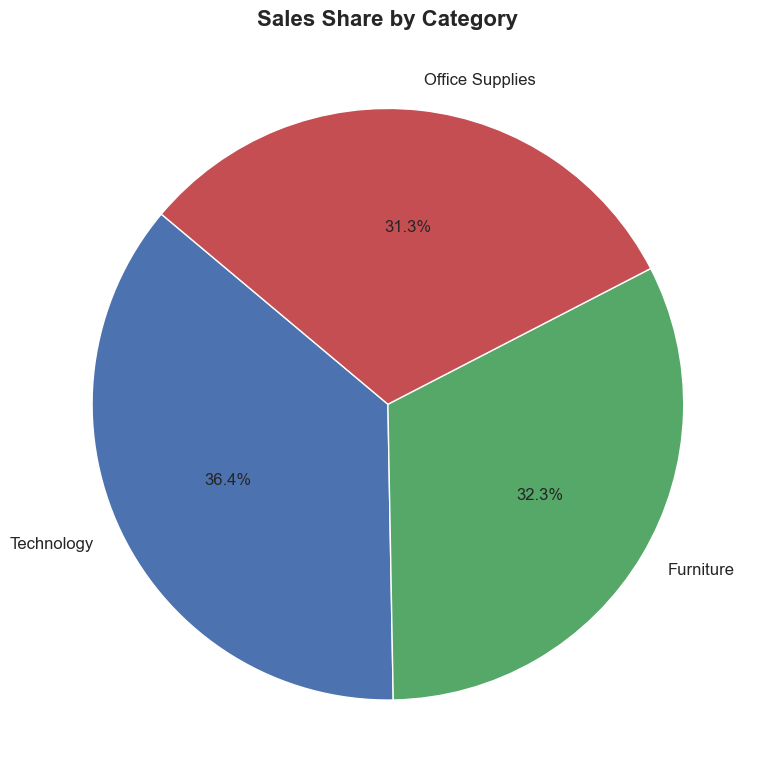

In [7]:
# SALES SHARE BY CATEGORY 

plt.figure(figsize=(8, 8))

plt.pie(
    category_performance['Total_Sales'],
    labels=category_performance['Category'],
    autopct='%1.1f%%',
    colors=['#4C72B0', '#55A868', '#C44E52'],
    startangle=140,
    textprops={'fontsize': 12}
)

plt.title('Sales Share by Category',
          fontsize=16, fontweight='bold')

plt.tight_layout()
save_fig('category_sales_share_pie.png')
plt.show()

In [8]:
category_performance.to_csv(
    'reports/tables/category_performance.csv', index=False
)

print("Category performance table saved")

Category performance table saved


### Insight


### Recommendation



## 2. Sales and Profit by Sub-Category

Business questions:

- **Which sub-category has the highest profit?**
- **Which sub-category has the lowest profit?**
- **Which sub-categories are generating losses?**

In [9]:
# SUB-CATEGORY PERFORMANCE

subcat_performance = df.groupby(
    ['Category', 'Sub-Category']
).agg(
    Total_Sales    = ('Sales',    'sum'),
    Total_Profit   = ('Profit',   'sum'),
    Total_Orders   = ('Order ID', 'nunique'),
    Total_Quantity = ('Quantity', 'sum'),
    Avg_Discount   = ('Discount', 'mean')
).reset_index()

# Profit Margin
subcat_performance['Profit_Margin_%'] = (
    subcat_performance['Total_Profit'] /
    subcat_performance['Total_Sales'] * 100
).round(2)

# Round avg discount
subcat_performance['Avg_Discount'] = (
    subcat_performance['Avg_Discount'] * 100
).round(2)

# Sort by Total Profit descending
subcat_performance = subcat_performance.sort_values(
    'Total_Profit', ascending=False
).reset_index(drop=True)

subcat_performance

,Category,Sub-Category,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Avg_Discount,Profit_Margin_%
0,Technology,Copiers,149528.03,55617.82,68,234,16.18,37.20
1,Technology,Phones,330007.05,44515.73,814,3289,15.46,13.49
2,Technology,Accessories,167380.32,41936.64,718,2976,7.85,25.05
3,Office Supplies,Paper,78479.21,34053.57,1191,5178,7.49,43.39
4,Office Supplies,Binders,203412.73,30221.76,1316,5974,37.23,14.86
5,Furniture,Chairs,328449.10,26590.17,576,2356,17.02,8.10
6,Office Supplies,Storage,223843.61,21278.83,777,3158,7.47,9.51
7,Office Supplies,Appliances,107532.16,18138.01,451,1729,16.65,16.87
8,Furniture,Furnishings,91705.16,13059.14,877,3563,13.83,14.24
9,Office Supplies,Envelopes,16476.40,6964.18,249,906,8.03,42.27


In [10]:
# LOSS-MAKING SUB-CATEGORIES 

loss_subcats = subcat_performance[
    subcat_performance['Total_Profit'] < 0
].sort_values('Total_Profit')

print("=" * 60)
print("LOSS-MAKING SUB-CATEGORIES")
print("=" * 60)

if len(loss_subcats) == 0:
    print("No loss-making sub-categories found!")
else:
    for _, row in loss_subcats.iterrows():
        print(f"\nSub-Category : {row['Sub-Category']}")
        print(f"  Category   : {row['Category']}")
        print(f"  Sales      : {format_currency(row['Total_Sales'])}")
        print(f"  Profit     : {format_currency(row['Total_Profit'])}")
        print(f"  Margin     : {format_percent(row['Profit_Margin_%'])}")
        print(f"  Avg Discount: {format_percent(row['Avg_Discount'])}")

LOSS-MAKING SUB-CATEGORIES

Sub-Category : Tables
  Category   : Furniture
  Sales      : $206,965.53
  Profit     : $-17,725.48
  Margin     : -8.56%
  Avg Discount: 26.13%

Sub-Category : Bookcases
  Category   : Furniture
  Sales      : $114,880.00
  Profit     : $-3,472.56
  Margin     : -3.02%
  Avg Discount: 21.11%

Sub-Category : Supplies
  Category   : Office Supplies
  Sales      : $46,673.54
  Profit     : $-1,189.10
  Margin     : -2.55%
  Avg Discount: 7.68%


 Saved: images/subcat_profit.png


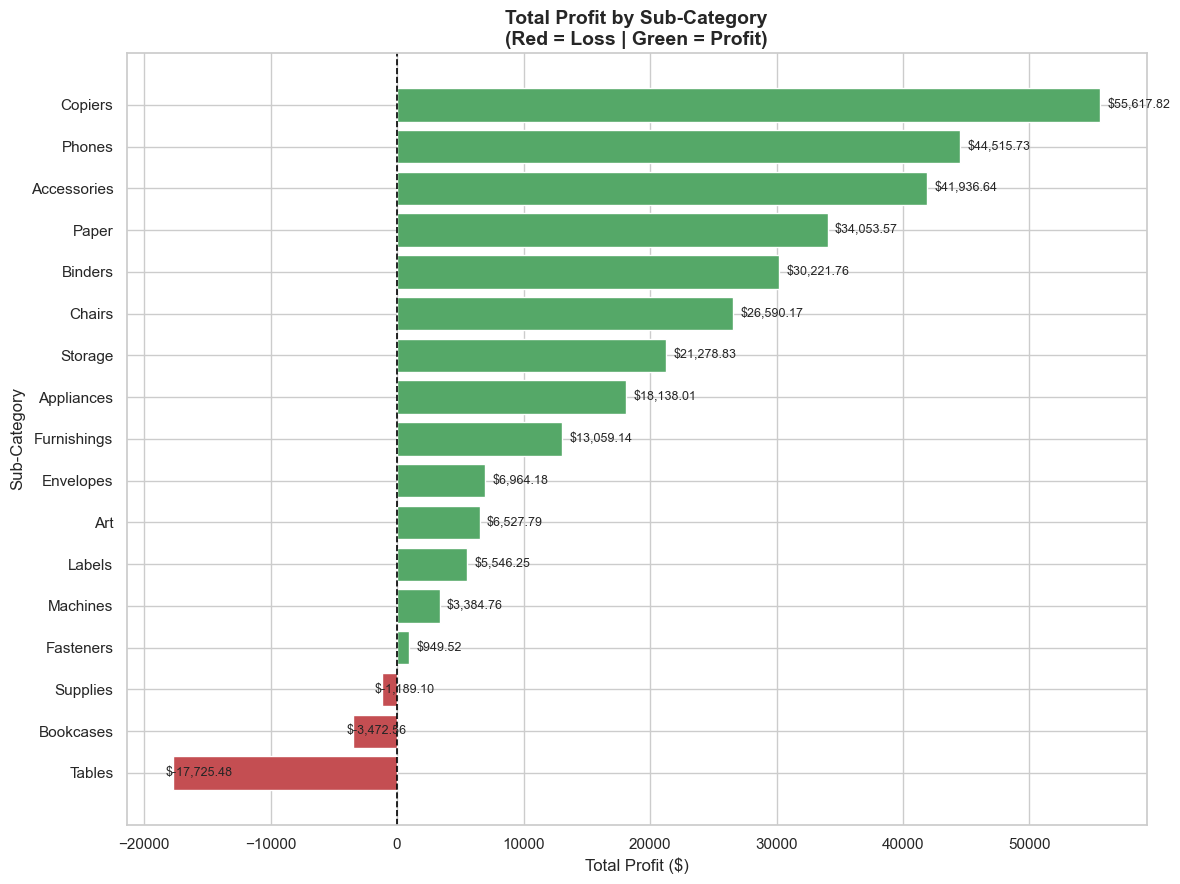

In [11]:
# VISUALIZE PROFIT BY SUB-CATEGORY 

subcat_sorted = subcat_performance.sort_values('Total_Profit')

# Color: red if loss, green if profit
colors = [
    '#C44E52' if p < 0 else '#55A868'
    for p in subcat_sorted['Total_Profit']
]

plt.figure(figsize=(12, 9))

bars = plt.barh(
    subcat_sorted['Sub-Category'],
    subcat_sorted['Total_Profit'],
    color=colors,
    edgecolor='white'
)

# Add value labels
for bar in bars:
    width = bar.get_width()
    label_x = width + (abs(subcat_sorted['Total_Profit'].max()) * 0.01)
    if width < 0:
        label_x = width - (abs(subcat_sorted['Total_Profit'].max()) * 0.01)
    plt.text(
        label_x,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

# Zero line
plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')

plt.title('Total Profit by Sub-Category\n(Red = Loss | Green = Profit)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Sub-Category')

plt.tight_layout()
save_fig('subcat_profit.png')
plt.show()

 Saved: images/subcat_sales.png


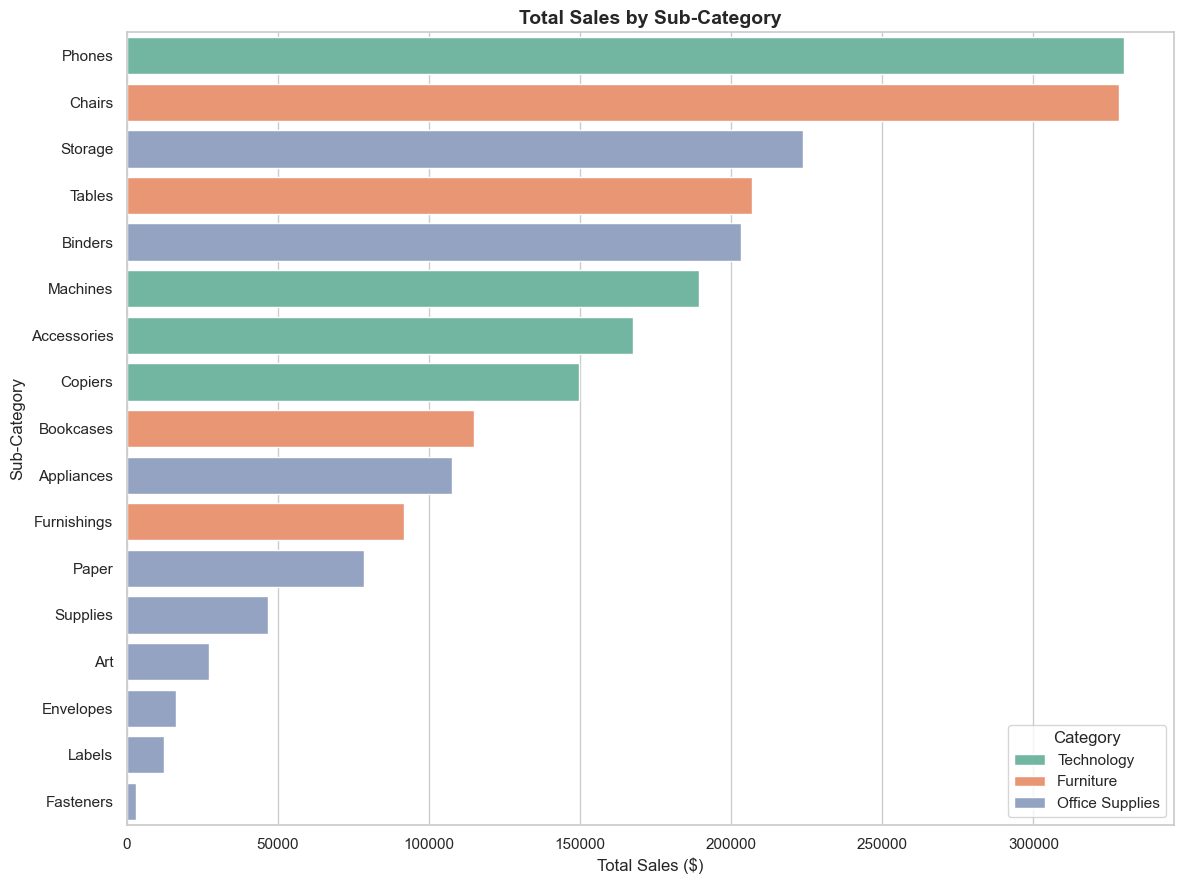

In [12]:
# VISUALIZE SALES BY SUB-CATEGORY

subcat_sales_sorted = subcat_performance.sort_values(
    'Total_Sales', ascending=False
)

plt.figure(figsize=(12, 9))

sns.barplot(
    data=subcat_sales_sorted,
    x='Total_Sales',
    y='Sub-Category',
    hue='Category',
    dodge=False,
    palette='Set2'
)

plt.title('Total Sales by Sub-Category',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.legend(title='Category', loc='lower right')

plt.tight_layout()
save_fig('subcat_sales.png')
plt.show()

 Saved: images/subcat_profit_margin.png


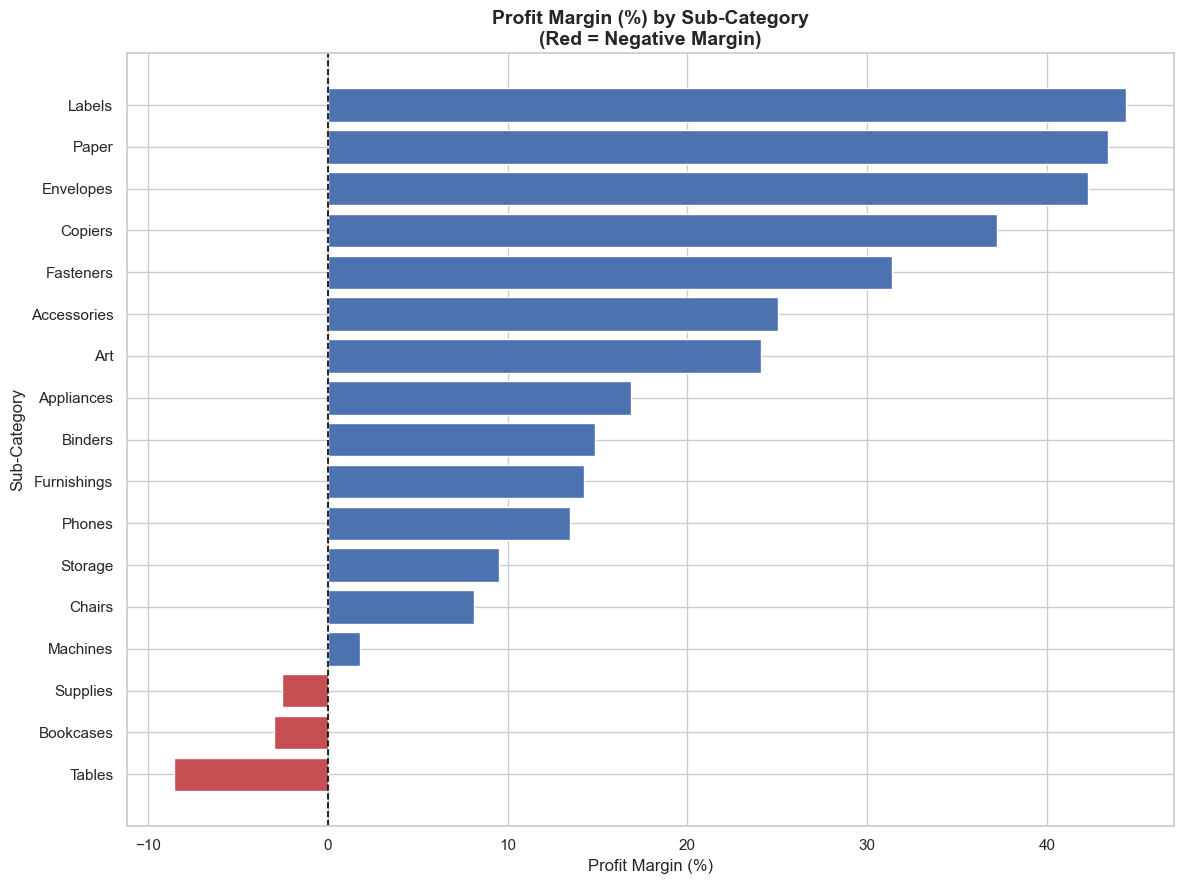

In [13]:
# PROFIT MARGIN BY SUB-CATEGORY

subcat_margin_sorted = subcat_performance.sort_values('Profit_Margin_%')

colors = [
    '#C44E52' if m < 0 else '#4C72B0'
    for m in subcat_margin_sorted['Profit_Margin_%']
]

plt.figure(figsize=(12, 9))

plt.barh(
    subcat_margin_sorted['Sub-Category'],
    subcat_margin_sorted['Profit_Margin_%'],
    color=colors,
    edgecolor='white'
)

plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')

plt.title('Profit Margin (%) by Sub-Category\n(Red = Negative Margin)',
          fontsize=14, fontweight='bold')
plt.xlabel('Profit Margin (%)')
plt.ylabel('Sub-Category')

plt.tight_layout()
save_fig('subcat_profit_margin.png')
plt.show()

In [14]:
subcat_performance.to_csv(
    'reports/tables/subcat_performance.csv', index=False
)

print("Sub-category performance table saved")

Sub-category performance table saved


### Insight



### Recommendation



## 3. Top 10 Products by Sales

Business question:

**Which products generate the most revenue?**

In [15]:
# TOP 10 PRODUCTS BY SALES

top10_sales = df.groupby('Product Name').agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Total_Orders  = ('Order ID', 'nunique'),
    Total_Quantity= ('Quantity', 'sum')
).reset_index()

top10_sales['Profit_Margin_%'] = (
    top10_sales['Total_Profit'] /
    top10_sales['Total_Sales'] * 100
).round(2)

top10_sales = top10_sales.sort_values(
    'Total_Sales', ascending=False
).head(10).reset_index(drop=True)

top10_sales

,Product Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
0,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,5,20,40.91
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04,10,31,28.24
2,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08,1,6,-8.00
3,HON 5400 Series Task Chairs for Big and Tall,21870.58,0.00,8,39,0.00
4,GBC DocuBind TL300 Electric Binding System,19823.48,2233.51,11,37,11.27
5,GBC Ibimaster 500 Manual ProClick Binding System,19024.50,760.98,9,48,4.00
6,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,8,38,37.07
7,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98,3,12,22.29
8,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,6,27,-10.45
9,High Speed Automatic Electric Letter Opener,17030.31,-262.00,3,11,-1.54


 Saved: images/top10_products_by_sales.png


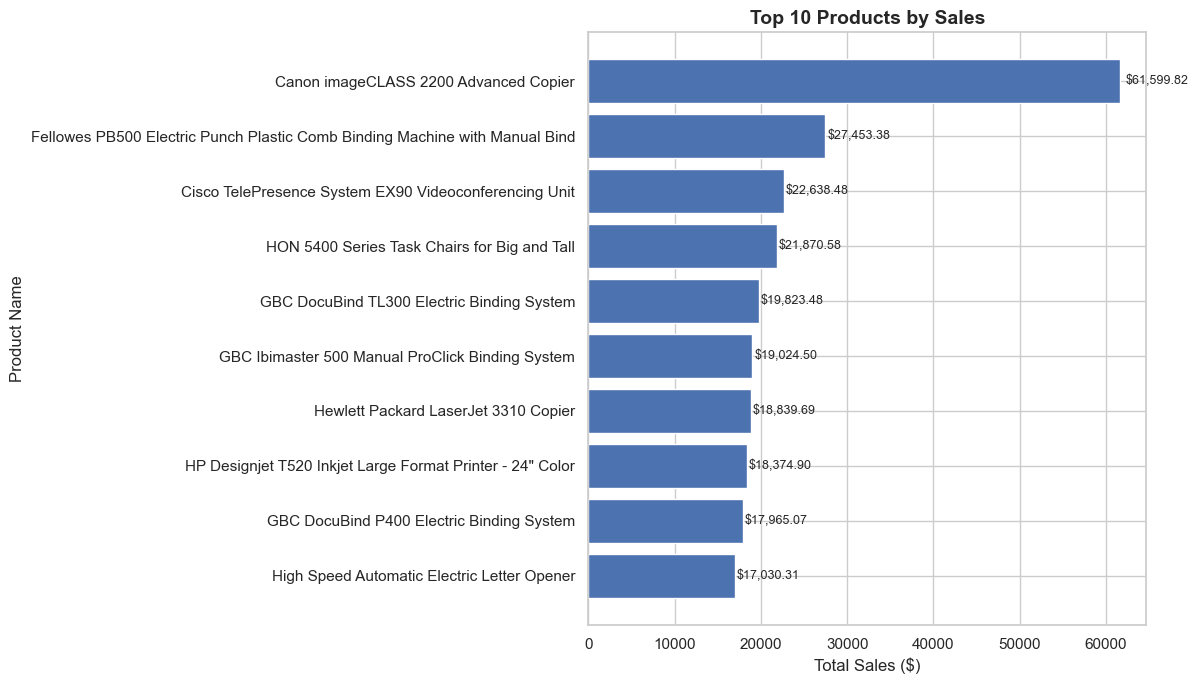

In [16]:
# VISUALIZE TOP 10 PRODUCTS BY SALES 

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_sales['Product Name'],
    top10_sales['Total_Sales'],
    color='#4C72B0',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 Products by Sales',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Sales ($)')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_products_by_sales.png')
plt.show()

In [17]:
top10_sales.to_csv(
    'reports/tables/top10_products_by_sales.csv', index=False
)

print("Top 10 products by sales saved")

Top 10 products by sales saved


## 4. Top 10 Products by Profit

Business question:

**Which products generate the most profit?**

In [18]:
# TOP 10 PRODUCTS BY PROFIT 

top10_profit = df.groupby('Product Name').agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Total_Orders  = ('Order ID', 'nunique'),
    Total_Quantity= ('Quantity', 'sum')
).reset_index()

top10_profit['Profit_Margin_%'] = (
    top10_profit['Total_Profit'] /
    top10_profit['Total_Sales'] * 100
).round(2)

top10_profit = top10_profit.sort_values(
    'Total_Profit', ascending=False
).head(10).reset_index(drop=True)

top10_profit

,Product Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Profit_Margin_%
0,Canon imageCLASS 2200 Advanced Copier,61599.82,25199.93,5,20,40.91
1,Fellowes PB500 Electric Punch Plastic Comb Bin...,27453.38,7753.04,10,31,28.24
2,Hewlett Packard LaserJet 3310 Copier,18839.69,6983.88,8,38,37.07
3,Canon PC1060 Personal Laser Copier,11619.83,4570.93,4,19,39.34
4,HP Designjet T520 Inkjet Large Format Printer ...,18374.90,4094.98,3,12,22.29
5,Ativa V4110MDD Micro-Cut Shredder,7699.89,3772.95,2,11,49.00
6,"3D Systems Cube Printer, 2nd Generation, Magenta",14299.89,3717.97,2,11,26.00
7,Plantronics Savi W720 Multi-Device Wireless He...,9367.29,3696.28,7,24,39.46
8,Ibico EPK-21 Electric Binding System,15875.92,3345.28,3,13,21.07
9,Zebra ZM400 Thermal Label Printer,6965.70,3343.54,2,6,48.00


 Saved: images/top10_products_by_profit.png


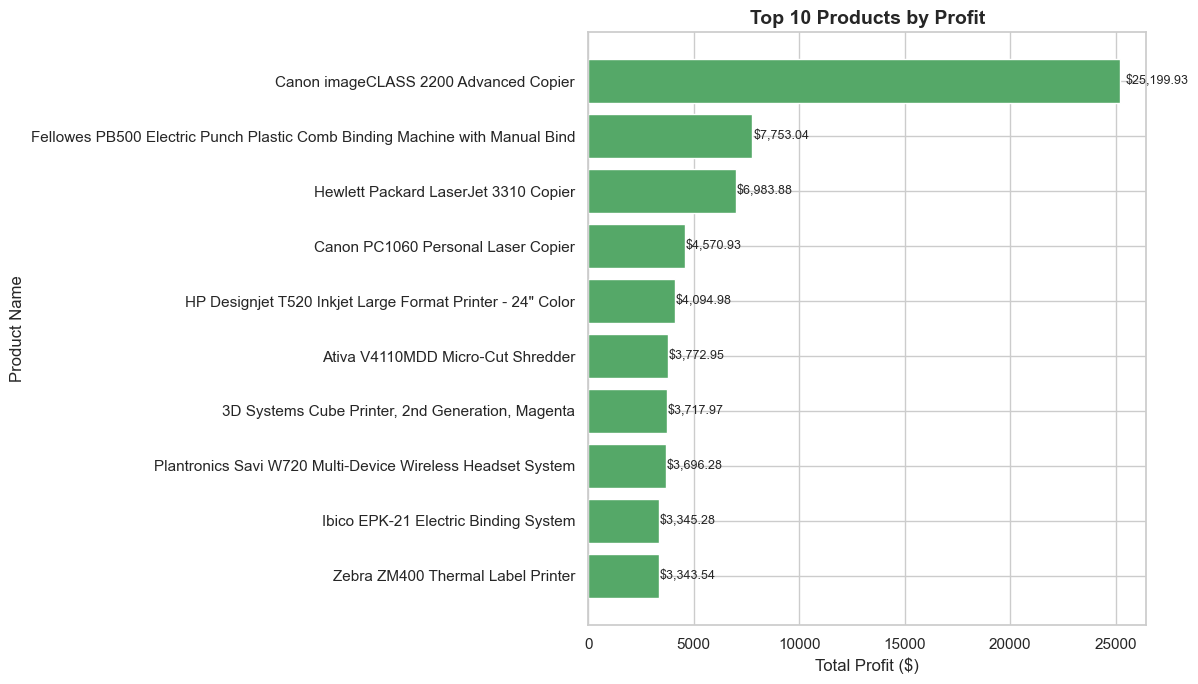

In [19]:
# VISUALIZE TOP 10 PRODUCTS BY PROFIT

plt.figure(figsize=(12, 7))

bars = plt.barh(
    top10_profit['Product Name'],
    top10_profit['Total_Profit'],
    color='#55A868',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width * 1.01,
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', fontsize=9
    )

plt.title('Top 10 Products by Profit',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('top10_products_by_profit.png')
plt.show()

In [20]:
top10_profit.to_csv(
    'reports/tables/top10_products_by_profit.csv', index=False
)

print("Top 10 products by profit saved")

Top 10 products by profit saved


## 5. Bottom 10 Products by Profit (Loss-Making Products)

Business question:

**Which products are causing the most financial loss?**

In [21]:
# BOTTOM 10 PRODUCTS BY PROFIT 

all_products = df.groupby('Product Name').agg(
    Total_Sales   = ('Sales',    'sum'),
    Total_Profit  = ('Profit',   'sum'),
    Total_Orders  = ('Order ID', 'nunique'),
    Total_Quantity= ('Quantity', 'sum'),
    Avg_Discount  = ('Discount', 'mean')
).reset_index()

all_products['Profit_Margin_%'] = (
    all_products['Total_Profit'] /
    all_products['Total_Sales'] * 100
).round(2)

all_products['Avg_Discount_%'] = (
    all_products['Avg_Discount'] * 100
).round(2)

bottom10_profit = all_products.sort_values(
    'Total_Profit', ascending=True
).head(10).reset_index(drop=True)

bottom10_profit

,Product Name,Total_Sales,Total_Profit,Total_Orders,Total_Quantity,Avg_Discount,Profit_Margin_%,Avg_Discount_%
0,Cubify CubeX 3D Printer Double Head Print,11099.96,-8879.97,3,9,0.53,-80.00,53.33
1,Lexmark MX611dhe Monochrome Laser Printer,16829.90,-4589.97,4,18,0.40,-27.27,40.00
2,Cubify CubeX 3D Printer Triple Head Print,7999.98,-3839.99,1,4,0.50,-48.00,50.00
3,Chromcraft Bull-Nose Wood Oval Conference Tabl...,9917.64,-2876.12,5,27,0.28,-29.00,28.00
4,Bush Advantage Collection Racetrack Conference...,9544.73,-1934.40,7,33,0.35,-20.27,35.00
5,GBC DocuBind P400 Electric Binding System,17965.07,-1878.17,6,27,0.45,-10.45,45.00
6,Cisco TelePresence System EX90 Videoconferenci...,22638.48,-1811.08,1,6,0.50,-8.00,50.00
7,Martin Yale Chadless Opener Electric Letter Op...,16656.20,-1299.18,6,22,0.10,-7.80,10.00
8,Balt Solid Wood Round Tables,6518.75,-1201.06,4,19,0.20,-18.42,20.00
9,BoxOffice By Design Rectangular and Half-Moon ...,1706.25,-1148.44,3,15,0.48,-67.31,48.33


 Saved: images/bottom10_products_by_profit.png


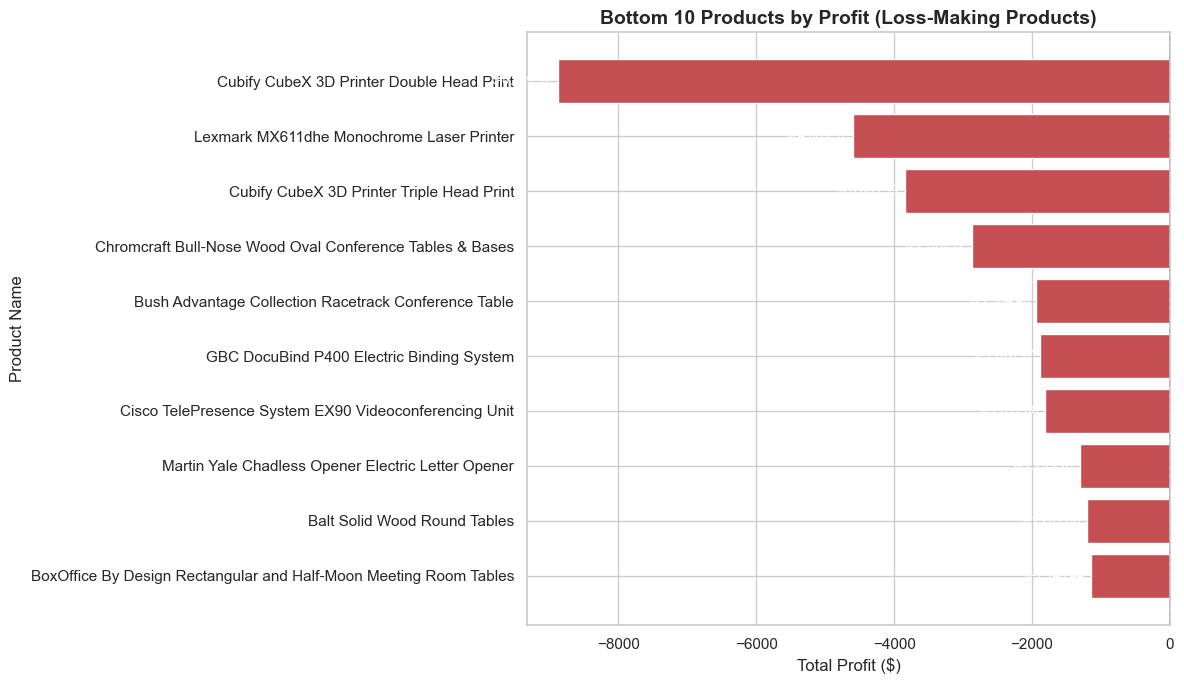

In [22]:
# VISUALIZE BOTTOM 10 PRODUCTS BY PROFIT

plt.figure(figsize=(12, 7))

bars = plt.barh(
    bottom10_profit['Product Name'],
    bottom10_profit['Total_Profit'],
    color='#C44E52',
    edgecolor='white'
)

for bar in bars:
    width = bar.get_width()
    plt.text(
        width - (abs(bottom10_profit['Total_Profit'].min()) * 0.01),
        bar.get_y() + bar.get_height() / 2,
        format_currency(width),
        va='center', ha='right', fontsize=9,
        color='white'
    )

plt.axvline(x=0, color='black', linewidth=1.2, linestyle='--')

plt.title('Bottom 10 Products by Profit (Loss-Making Products)',
          fontsize=14, fontweight='bold')
plt.xlabel('Total Profit ($)')
plt.ylabel('Product Name')
plt.gca().invert_yaxis()

plt.tight_layout()
save_fig('bottom10_products_by_profit.png')
plt.show()

In [23]:
bottom10_profit.to_csv(
    'reports/tables/bottom10_products_by_profit.csv', index=False
)

print("Bottom 10 products by profit saved")

Bottom 10 products by profit saved


In [ ]:
### Insight



### Recommendation



## 6. Final Summary

In [25]:
# PRODUCT ANALYSIS FINAL SUMMARY 

best_category_sales = category_performance.iloc[0]
best_category_profit = category_performance.sort_values(
    'Total_Profit', ascending=False
).iloc[0]

best_subcat_profit = subcat_performance.iloc[0]
worst_subcat_profit = subcat_performance.iloc[-1]

best_product_sales = top10_sales.iloc[0]
best_product_profit = top10_profit.iloc[0]
worst_product_profit = bottom10_profit.iloc[0]

print("=" * 60)
print("PRODUCT ANALYSIS SUMMARY")
print("=" * 60)

print(f"\n📦 CATEGORY")
print(f"  Highest Sales:   {best_category_sales['Category']} "
      f"({format_currency(best_category_sales['Total_Sales'])})")
print(f"  Highest Profit:  {best_category_profit['Category']} "
      f"({format_currency(best_category_profit['Total_Profit'])})")

print(f"\n🏷️ SUB-CATEGORY")
print(f"  Best Profit:     {best_subcat_profit['Sub-Category']} "
      f"({format_currency(best_subcat_profit['Total_Profit'])})")
print(f"  Worst Profit:    {worst_subcat_profit['Sub-Category']} "
      f"({format_currency(worst_subcat_profit['Total_Profit'])})")

loss_count = len(subcat_performance[subcat_performance['Total_Profit'] < 0])
print(f"  Loss-making sub-categories: {loss_count}")

print(f"\n🥇 PRODUCTS")
print(f"  Top by Sales:    {best_product_sales['Product Name'][:40]} "
      f"({format_currency(best_product_sales['Total_Sales'])})")
print(f"  Top by Profit:   {best_product_profit['Product Name'][:40]} "
      f"({format_currency(best_product_profit['Total_Profit'])})")
print(f"  Most Loss:       {worst_product_profit['Product Name'][:40]} "
      f"({format_currency(worst_product_profit['Total_Profit'])})")


PRODUCT ANALYSIS SUMMARY

📦 CATEGORY
  Highest Sales:   Technology ($836,154.03)
  Highest Profit:  Technology ($145,454.95)

🏷️ SUB-CATEGORY
  Best Profit:     Copiers ($55,617.82)
  Worst Profit:    Tables ($-17,725.48)
  Loss-making sub-categories: 3

🥇 PRODUCTS
  Top by Sales:    Canon imageCLASS 2200 Advanced Copier ($61,599.82)
  Top by Profit:   Canon imageCLASS 2200 Advanced Copier ($25,199.93)
  Most Loss:       Cubify CubeX 3D Printer Double Head Prin ($-8,879.97)


## Summary

In this notebook, we analyzed product performance across categories, 
sub-categories, and individual products.

### Key Areas Covered
- Category-level sales and profit performance
- Sub-category profitability and loss identification
- Top 10 products by sales
- Top 10 products by profit
- Bottom 10 loss-making products

### Main Takeaways
- Revenue and profitability at the product level do not always align.
- Some sub-categories and individual products are generating consistent losses.
- Discount rates appear to be linked to profitability issues in certain products.

### Next Step
Notebook 04 will focus on **Regional Analysis**, including:
- Sales and profit by region
- Top and bottom performing states
- Geographic distribution of profitability
- States with negative profit